In [1]:
import pandas as pd
import numpy as np
from utils import plot
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [2]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

df_amounts = pd.read_csv('wbtc_token_amounts_data.csv')
total_supply = df_amounts['island_token_balance'].values
stable_token_balance = df_amounts['honey_balance'].values
vol_token_balance = df_amounts['wbtc_balance'].values

"""total_supply = total_supply[len(total_supply) - len(nav):]
stable_token_balance = stable_token_balance[len(stable_token_balance) - len(nav):]
vol_token_balance = vol_token_balance[len(vol_token_balance) - len(nav):]"""

'total_supply = total_supply[len(total_supply) - len(nav):]\nstable_token_balance = stable_token_balance[len(stable_token_balance) - len(nav):]\nvol_token_balance = vol_token_balance[len(vol_token_balance) - len(nav):]'

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


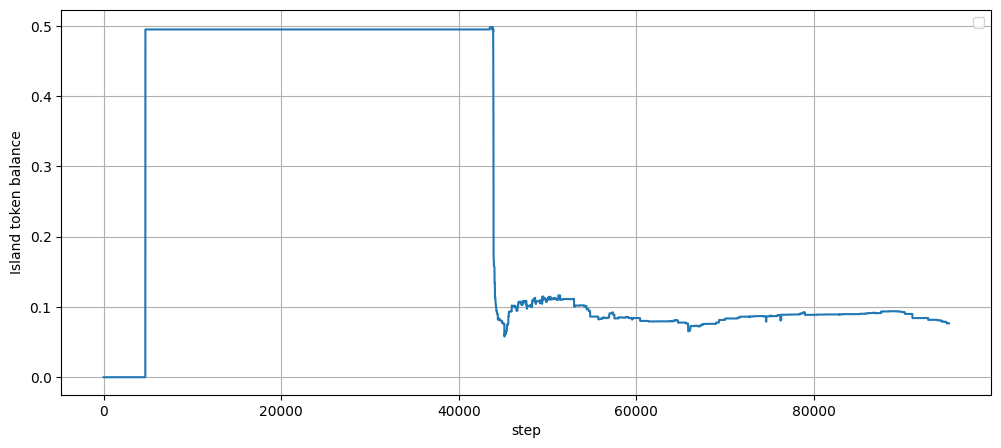

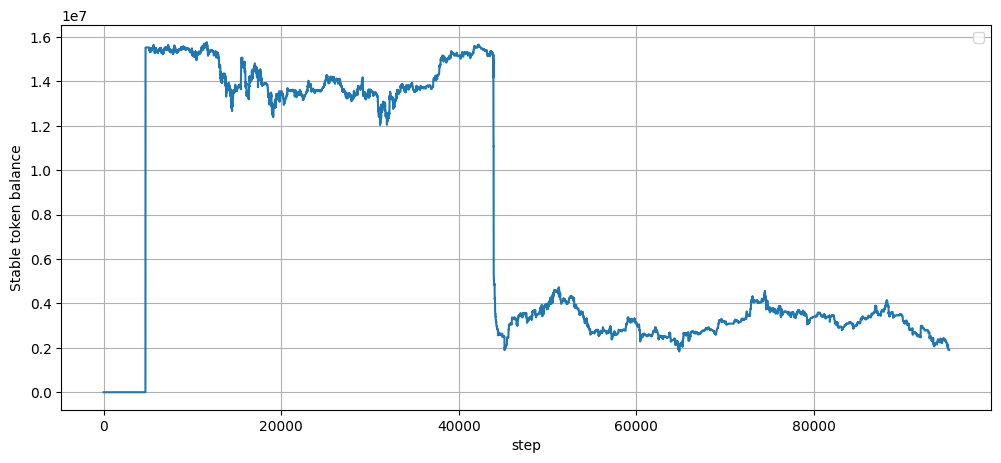

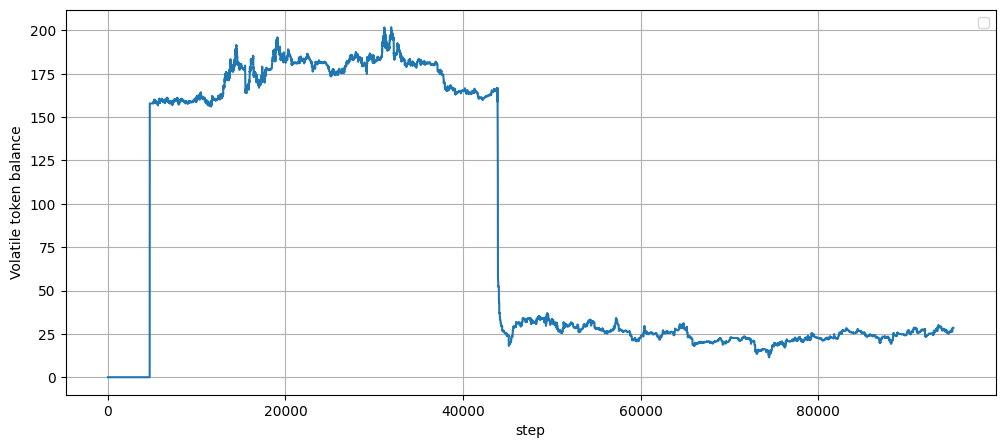

In [3]:
plot(
    [total_supply],
    'step',
    'Island token balance'
)

plot(
    [stable_token_balance],
    'step',
    'Stable token balance'
)

plot(
    [vol_token_balance],
    'step',
    'Volatile token balance'
)

In [77]:
def gbm_diagnostics(S, dt=1/252, max_lag=20):
    S = np.asarray(S); assert S.ndim == 1 and np.all(S > 0)
    r = np.diff(np.log(S))  # log-returns
    n = r.size
    m, s = r.mean(), r.std(ddof=1)

    # Parameter estimates for GBM
    sigma_hat = s / np.sqrt(dt)
    mu_hat = 0.5 * sigma_hat**2 + m / dt

    # Normality tests on returns
    jb_stat, jb_p = stats.jarque_bera(r)
    sh_p = stats.shapiro(r[:min(n, 5000)]).pvalue  # Shapiro limited to 5000
    z = (r - m) / s
    ks_p = stats.kstest(z, 'norm').pvalue

    # Independence: Ljung-Box on returns and squared returns
    lb_r_p = acorr_ljungbox(r, lags=[max_lag], return_df=True)['lb_pvalue'].iloc[0]
    lb_r2_p = acorr_ljungbox((r - m)**2, lags=[max_lag], return_df=True)['lb_pvalue'].iloc[0]

    # ARCH LM test (heteroskedasticity)
    arch_stat, arch_p, _, _ = het_arch(r, maxlag=5)

    # Stationarity of levels (GBM implies non-stationary levels, stationary returns)
    adf_lvl_p = adfuller(S)[1]
    adf_ret_p = adfuller(r)[1]

    # Split-sample stability
    h = n // 2
    m1, s1 = r[:h].mean(), r[:h].std(ddof=1)
    m2, s2 = r[h:].mean(), r[h:].std(ddof=1)
    # variance equality (Levene) and mean equality (t-test)
    lev_p = stats.levene(r[:h], r[h:]).pvalue
    t_p = stats.ttest_ind(r[:h], r[h:], equal_var=False).pvalue

    # Variance-time scaling: check var(k-step)/k ~ var(1-step)
    ks = np.array([1, 2, 5, 10, 20])
    var_k = []
    for k in ks:
        rk = r.reshape(-1)  # ensure 1D
        rk = rk[: n - (n % k)]  # trim to multiple of k
        agg = rk.reshape(-1, k).sum(axis=1)
        var_k.append(agg.var(ddof=1))
    var_k = np.array(var_k)
    scaling_errors = (var_k / (var_k[0] * ks)) - 1.0  # 0 is perfect

    # Log-likelihood under i.i.d. normal for returns
    ll = np.sum(stats.norm.logpdf(r, loc=m, scale=s))
    aic_norm = 2*2 - 2*ll  # 2 params: mean & std

    print("=== GBM DIAGNOSTICS ===")
    print(f"n={n}, dt={dt}")
    print(f"mu_hat={mu_hat:.6f}  sigma_hat={sigma_hat:.6f}  (annualized)")
    print("\n-- Normality of returns --")
    print(f"Jarque-Bera p={jb_p:.3e}, Shapiro p={sh_p:.3e}, KS p={ks_p:.3e}")
    print("-- Independence --")
    print(f"Ljung-Box returns (lag {max_lag}) p={lb_r_p:.3e}")
    print(f"Ljung-Box squared returns (lag {max_lag}) p={lb_r2_p:.3e}")
    print(f"ARCH LM p={arch_p:.3e}")
    print("-- Stationarity --")
    print(f"ADF levels p={adf_lvl_p:.3e}  (expect non-stationary)")
    print(f"ADF returns p={adf_ret_p:.3e}  (expect stationary)")
    print("-- Stability (first half vs second half) --")
    print(f"Mean change p={t_p:.3e}, Var equality (Levene) p={lev_p:.3e}")
    print("-- Variance-time scaling (ideal ~0):")
    for k, err in zip(ks, scaling_errors):
        print(f"  k={k:>2d}: rel error = {err:+.3%}")
    print(f"-- Likelihood --\nAIC (i.i.d. normal returns) = {aic_norm:.1f}")
    print("=== END ===")

    return {
        "mu_hat": mu_hat, "sigma_hat": sigma_hat, "jb_p": jb_p, "shapiro_p": sh_p,
        "ks_p": ks_p, "lb_ret_p": lb_r_p, "lb_sqret_p": lb_r2_p, "arch_p": arch_p,
        "adf_level_p": adf_lvl_p, "adf_return_p": adf_ret_p,
        "t_p": t_p, "levene_p": lev_p, "scaling_errors": scaling_errors,
        "aic_norm": aic_norm
    }

In [78]:
gbm_diagnostics(total_supply)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20268\3099199808.py:22: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, _, _ = het_arch(r, maxlag=5)


=== GBM DIAGNOSTICS ===
n=48179, dt=0.003968253968253968
mu_hat=-0.001149  sigma_hat=0.029393  (annualized)

-- Normality of returns --
Jarque-Bera p=0.000e+00, Shapiro p=9.975e-94, KS p=0.000e+00
-- Independence --
Ljung-Box returns (lag 20) p=5.047e-06
Ljung-Box squared returns (lag 20) p=1.000e+00
ARCH LM p=9.965e-01
-- Stationarity --
ADF levels p=3.531e-01  (expect non-stationary)
ADF returns p=0.000e+00  (expect stationary)
-- Stability (first half vs second half) --
Mean change p=7.509e-01, Var equality (Levene) p=1.457e-07
-- Variance-time scaling (ideal ~0):
  k= 1: rel error = +0.000%
  k= 2: rel error = +0.322%
  k= 5: rel error = -2.659%
  k=10: rel error = -6.779%
  k=20: rel error = -7.079%
-- Likelihood --
AIC (i.i.d. normal returns) = -469528.7
=== END ===


{'mu_hat': np.float64(-0.0011487684820321888),
 'sigma_hat': np.float64(0.02939274707018989),
 'jb_p': np.float64(0.0),
 'shapiro_p': np.float64(9.974703911739878e-94),
 'ks_p': np.float64(0.0),
 'lb_ret_p': np.float64(5.046879600665248e-06),
 'lb_sqret_p': np.float64(0.9999995183884895),
 'arch_p': np.float64(0.996535882631615),
 'adf_level_p': np.float64(0.35310660366472835),
 'adf_return_p': 0.0,
 't_p': np.float64(0.7509328690035054),
 'levene_p': np.float64(1.4565980395575904e-07),
 'scaling_errors': array([ 0.        ,  0.00321878, -0.02658762, -0.06779371, -0.07078551]),
 'aic_norm': np.float64(-469528.65745309927)}

In [79]:
gbm_diagnostics(vol_token_balance)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20268\3099199808.py:22: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, _, _ = het_arch(r, maxlag=5)


=== GBM DIAGNOSTICS ===
n=48179, dt=0.003968253968253968
mu_hat=0.000473  sigma_hat=0.045393  (annualized)

-- Normality of returns --
Jarque-Bera p=0.000e+00, Shapiro p=1.193e-87, KS p=0.000e+00
-- Independence --
Ljung-Box returns (lag 20) p=0.000e+00
Ljung-Box squared returns (lag 20) p=1.468e-01
ARCH LM p=1.856e-03
-- Stationarity --
ADF levels p=6.084e-02  (expect non-stationary)
ADF returns p=0.000e+00  (expect stationary)
-- Stability (first half vs second half) --
Mean change p=2.500e-01, Var equality (Levene) p=6.844e-01
-- Variance-time scaling (ideal ~0):
  k= 1: rel error = +0.000%
  k= 2: rel error = +17.747%
  k= 5: rel error = +40.967%
  k=10: rel error = +64.684%
  k=20: rel error = +90.573%
-- Likelihood --
AIC (i.i.d. normal returns) = -427650.2
=== END ===


{'mu_hat': np.float64(0.00047347578761676565),
 'sigma_hat': np.float64(0.045393154654959314),
 'jb_p': np.float64(0.0),
 'shapiro_p': np.float64(1.1931862868246577e-87),
 'ks_p': np.float64(0.0),
 'lb_ret_p': np.float64(0.0),
 'lb_sqret_p': np.float64(0.1468133039150359),
 'arch_p': np.float64(0.0018560349390025208),
 'adf_level_p': np.float64(0.06083762728512375),
 'adf_return_p': 0.0,
 't_p': np.float64(0.2499591948934236),
 'levene_p': np.float64(0.6844451619762195),
 'scaling_errors': array([0.        , 0.17747444, 0.40966666, 0.64684282, 0.9057257 ]),
 'aic_norm': np.float64(-427650.1823912332)}

In [80]:
gbm_diagnostics(stable_token_balance)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20268\3099199808.py:22: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, _, _ = het_arch(r, maxlag=5)


=== GBM DIAGNOSTICS ===
n=48179, dt=0.003968253968253968
mu_hat=-0.002248  sigma_hat=0.041933  (annualized)

-- Normality of returns --
Jarque-Bera p=0.000e+00, Shapiro p=1.157e-88, KS p=0.000e+00
-- Independence --
Ljung-Box returns (lag 20) p=1.077e-286
Ljung-Box squared returns (lag 20) p=6.503e-01
ARCH LM p=1.201e-01
-- Stationarity --
ADF levels p=4.628e-01  (expect non-stationary)
ADF returns p=0.000e+00  (expect stationary)
-- Stability (first half vs second half) --
Mean change p=4.034e-01, Var equality (Levene) p=2.012e-06
-- Variance-time scaling (ideal ~0):
  k= 1: rel error = +0.000%
  k= 2: rel error = +15.427%
  k= 5: rel error = +37.325%
  k=10: rel error = +55.693%
  k=20: rel error = +70.955%
-- Likelihood --
AIC (i.i.d. normal returns) = -435290.3
=== END ===


{'mu_hat': np.float64(-0.0022482289244639127),
 'sigma_hat': np.float64(0.041932990593614355),
 'jb_p': np.float64(0.0),
 'shapiro_p': np.float64(1.1570829587529624e-88),
 'ks_p': np.float64(0.0),
 'lb_ret_p': np.float64(1.0771807867456898e-286),
 'lb_sqret_p': np.float64(0.6503278027138407),
 'arch_p': np.float64(0.12011377673903105),
 'adf_level_p': np.float64(0.4628250844494909),
 'adf_return_p': 0.0,
 't_p': np.float64(0.4033700750470578),
 'levene_p': np.float64(2.012464039478519e-06),
 'scaling_errors': array([0.        , 0.15427364, 0.37324576, 0.5569261 , 0.70954883]),
 'aic_norm': np.float64(-435290.2572213638)}

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


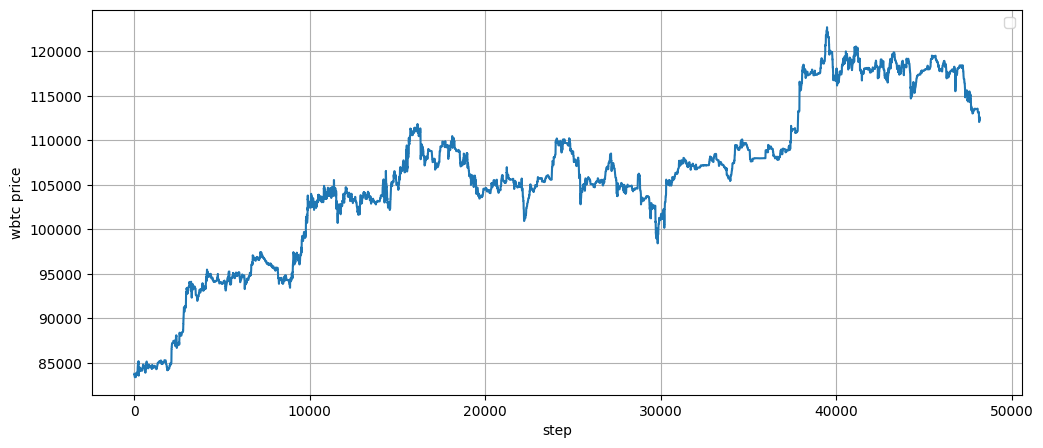

In [81]:
plot(
    [vol_token_price],
    'step',
    'wbtc price'
)

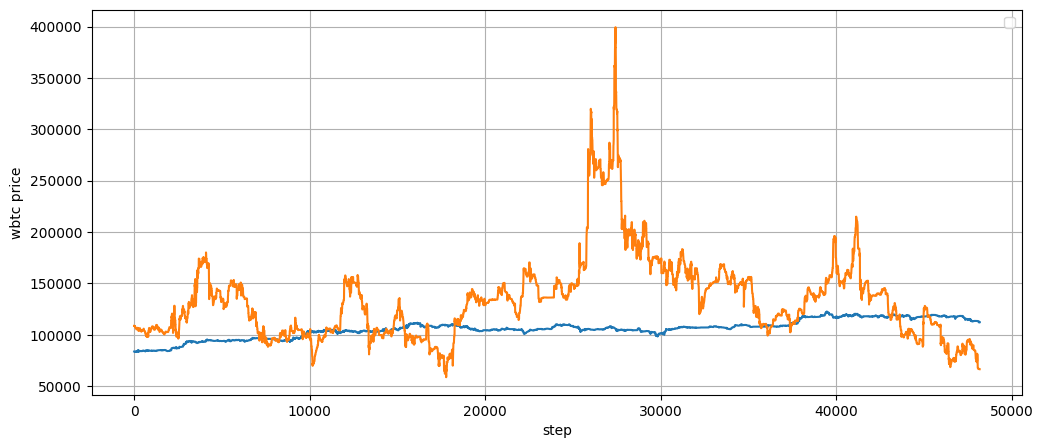

In [82]:
plot(
    [vol_token_price, stable_token_balance/vol_token_balance],
    'step',
    'wbtc price'
)

In [83]:
S = np.array([vol_token_price, vol_token_balance, stable_token_balance, total_supply])
S = S.T
logS = np.log(S)
print(S.shape)
R = np.diff(logS, axis=0)
print(R.shape)

(48180, 4)
(48179, 4)


In [84]:
corr_matrix = np.corrcoef(R.T)
cov_matrix = np.cov(R.T)

display(corr_matrix)
display(cov_matrix)

array([[ 1.        ,  0.0032052 ,  0.00590079,  0.00512621],
       [ 0.0032052 ,  1.        , -0.0594688 ,  0.64619317],
       [ 0.00590079, -0.0594688 ,  1.        ,  0.70239515],
       [ 0.00512621,  0.64619317,  0.70239515,  1.        ]])

array([[ 2.36992947e-07,  4.46182456e-09,  7.58810585e-09,
         4.62066415e-09],
       [ 4.46182456e-09,  8.17674004e-06, -4.49194953e-07,
         3.42130952e-06],
       [ 7.58810585e-09, -4.49194953e-07,  6.97768135e-06,
         3.43539734e-06],
       [ 4.62066415e-09,  3.42130952e-06,  3.43539734e-06,
         3.42830786e-06]])

In [85]:
from sklearn.decomposition import PCA

pca = PCA().fit(R)
explained = pca.explained_variance_ratio_

print('explained:', explained)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=[f"S{i+1}" for i in range(R.shape[1])]
)

print(loadings)

explained: [0.56121412 0.42228641 0.01259269 0.00390678]
         PC1       PC2       PC3       PC4
S1  0.000876  0.000513  0.999975  0.006997
S2  0.708521 -0.600366  0.002282 -0.370881
S3  0.440011  0.786735  0.002240 -0.432934
S4  0.551713  0.143552 -0.006306  0.821563


In [86]:
from statsmodels.tsa.stattools import coint

for i in range(4):
    for j in range(i+1,4):
        stat, p, _ = coint(S[:,i], S[:,j])
        print(i, j, p)

0 1 0.5029661771298823
0 2 0.2668892986588392
0 3 0.3955239267370301
1 2 0.18574425957201174
1 3 0.23965738242728218
2 3 0.24595917606759327


In [96]:
import numpy as np

def simulate_4series(
    n, dt,
    S0,          # length-4 array of initial prices
    mu,          # length-4 annualized drift
    sigma,       # length-4 annualized vol
    rho24 = 0.65,       # target Corr(S2,S4) == Corr(S3,S4)
    k = 0.95,       # factor share for S2/S3 (0<k<=1)
    c = 0.7,       # S4 common-factor loading (0< c <1)
    seed=None
):

    rng = np.random.default_rng(seed)

    S0 = np.asarray(S0, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)

    r = np.sqrt(1/float(rho24)**2 - 1)
    a = k / np.sqrt(1 + r*r)
    b = r * a

    G = np.array([
        [0.0, 0.0],
        [a,  -b ],
        [a,   b ],
        [c,  0.0]
    ])

    norms2 = np.sum(G**2, axis=1)
    if np.any(norms2 >= 1):
        raise ValueError("Choose smaller k or c: some loading norm >=1")
    w_id = np.sqrt(1.0 - norms2)   # shape (4,)

    Z_common = rng.standard_normal((n, 2))  # factor shocks
    Z_idio   = rng.standard_normal((n, 4))  # idio shocks

    u = (Z_common @ G.T) + Z_idio * w_id

    drift = (mu - 0.5 * sigma**2) * dt
    vol   = sigma * np.sqrt(dt)
    R = drift + u * vol      

    S = np.empty((n+1, 4))
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(R, axis=0))

    return S.T, R.T

In [88]:
print(np.std(np.log(vol_token_balance)))
print(np.std(np.log(stable_token_balance)))
print(np.std(np.log(total_supply)))
print(np.std(np.log(vol_token_price)))

0.1764965560805584
0.17615395829118863
0.10679331573472989
0.08522254220295641


(4, 4001)


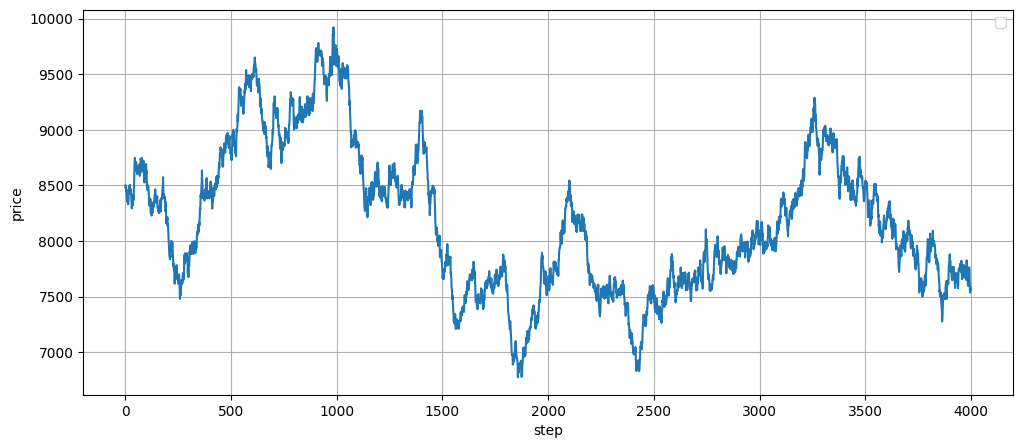

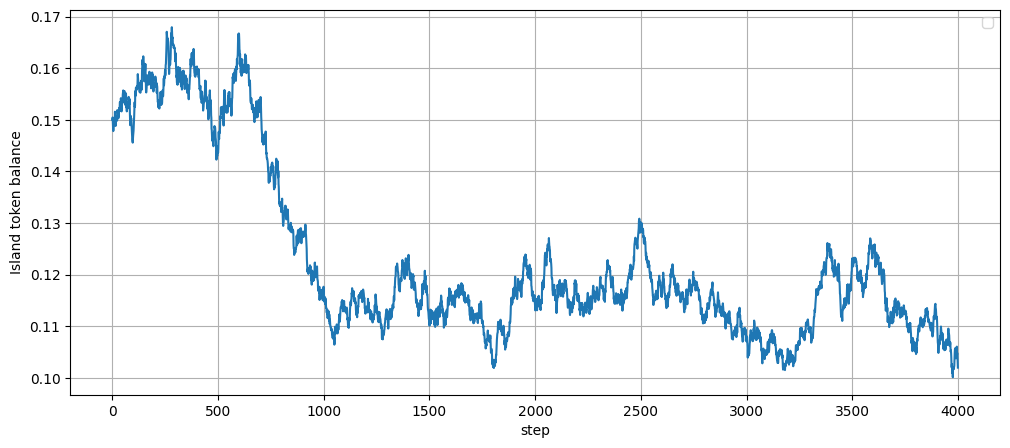

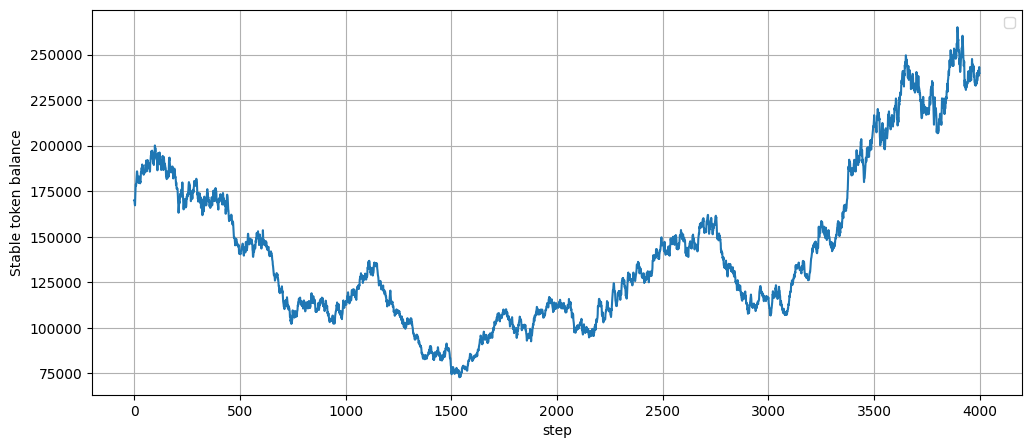

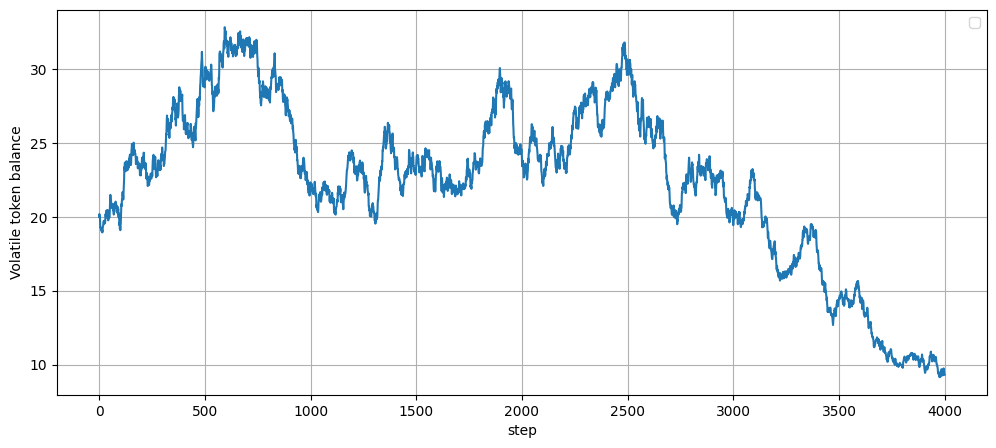

In [105]:
S, _ = simulate_4series(
    4000,
    1/250,
    [8500,20,20*8500,0.15],
    [0,0,0,0],
    [0.08522254220295641, 0.1764965560805584, 0.17615395829118863, 0.10679331573472989]
)

print(S.shape)

plot(
    [S[0]],
    'step',
    'price'
)

plot(
    [S[3]],
    'step',
    'Island token balance'
)

plot(
    [S[2]],
    'step',
    'Stable token balance'
)

plot(
    [S[1]],
    'step',
    'Volatile token balance'
)

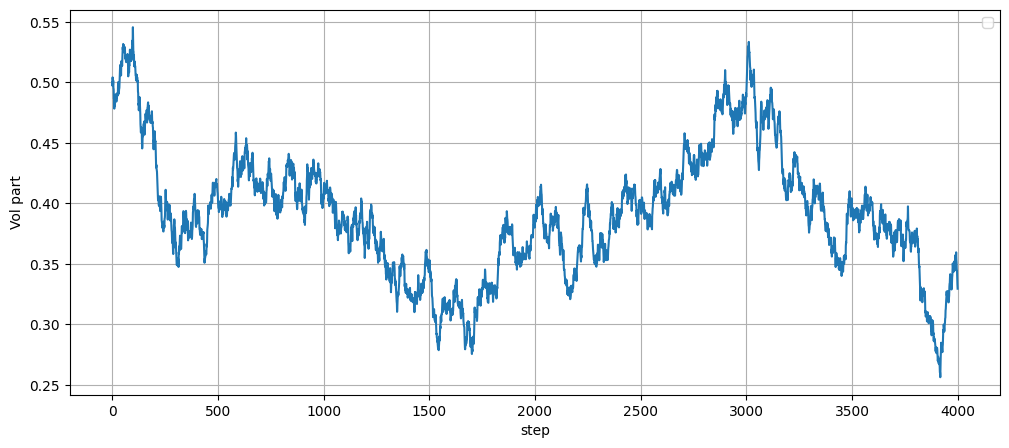

In [103]:
plot(
    [S[1]*S[0]/(S[1]*S[0] + S[2])],
    'step',
    'Vol part'
)

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


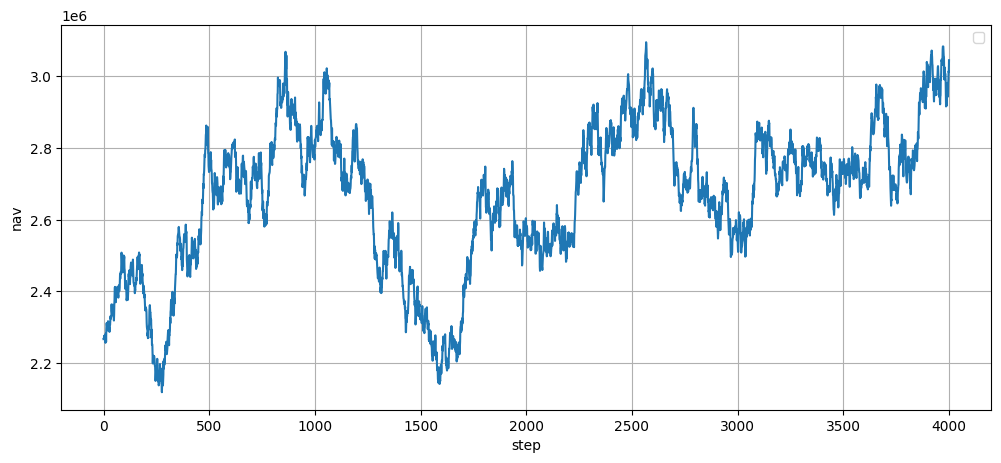

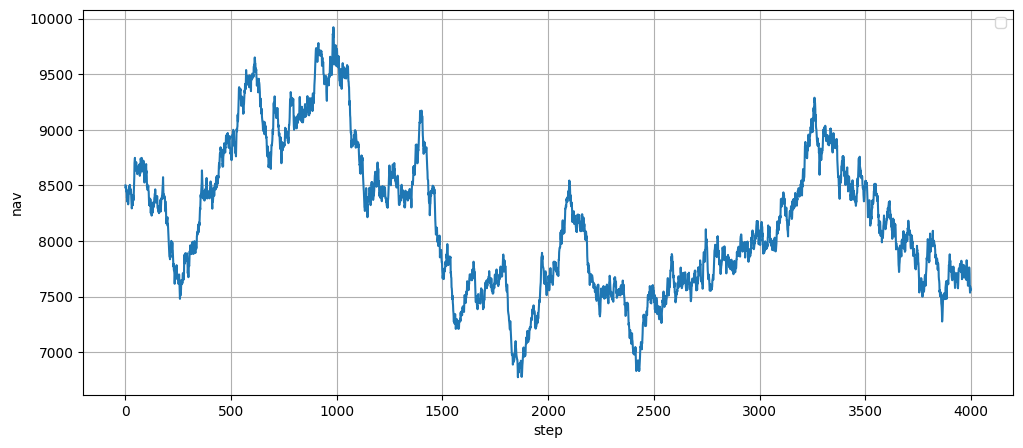

In [108]:
plot(
    [(S[1]*S[0] + S[2])/S[3]],
    'step',
    'nav'
)

plot(
    [S[0]],
    'step',
    'nav'
)

In [91]:
print(np.std(S[0]))
print(np.std(10*S[0]))

0.12005828524996653
1.2005828524996653
